![Banner](../../images/01_banner.png)


# 1.3 Second-order and Distance-based Summary Functions

**Part:** 1: Point Pattern Analysis (Chapter 1.3 of 5)

**Dataset:** Buffalo crime incidents, 2018, a 2,500-event working subsample of the deduplicated pattern
(`data/crime_data_2018.csv`, `data/buffalo_city.shp`)

**Focus:** Quantifying *interaction* between events — nearest-neighbour statistics (Clark–Evans, G, F, J) and
Ripley's K, L, and pair correlation functions

**Library:** `spatialstats.pointpattern` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Second-order Structure: What These Functions Measure](#2.-Second-order-Structure:-What-These-Functions-Measure)

3. [Nearest-neighbour Methods](#3.-Nearest-neighbour-Methods)

   - 3.1 [The Clark–Evans index](#3.1-The-Clark–Evans-index)

   - 3.2 [G and F: event and empty-space distributions](#3.2-G-and-F:-event-and-empty-space-distributions)

   - 3.3 [J: a combined diagnostic](#3.3-J:-a-combined-diagnostic)

4. [Ripley's K, L and the Pair Correlation Function](#4.-Ripley's-K,-L-and-the-Pair-Correlation-Function)

   - 4.1 [Ripley's K function](#4.1-Ripley's-K-function)

   - 4.2 [The variance-stabilised L function](#4.2-The-variance-stabilised-L-function)

   - 4.3 [The pair correlation function g(r)](#4.3-The-pair-correlation-function-g(r))

   - 4.4 [Edge corrections](#4.4-Edge-corrections)

5. [Python Setup](#5.-Python-Setup)

6. [Data: A Working Subsample](#6.-Data:-A-Working-Subsample)

7. [Clark–Evans Nearest-neighbour Test](#7.-Clark–Evans-Nearest-neighbour-Test)

8. [G, F and J Functions](#8.-G,-F-and-J-Functions)

9. [Ripley's K and L Functions](#9.-Ripley's-K-and-L-Functions)

10. [Pair Correlation Function](#10.-Pair-Correlation-Function)

11. [Comparing Edge Corrections](#11.-Comparing-Edge-Corrections)

12. [Summary and Conclusions](#12.-Summary-and-Conclusions)

13. [Resources](#13.-Resources)


***
## 1. Overview

Chapter 1.2 established that crime intensity $\lambda(\mathbf{s})$ varies strongly across Buffalo. This
chapter asks a logically separate question: **given** that intensity, are individual events attracted to or
repelled by *each other*, at some spatial scale? A neighbourhood can have high crime intensity purely because
it has more opportunity targets, with no event-to-event interaction at all; or events can genuinely cluster —
one incident increasing the local chance of another (a fight escalating, opportunistic follow-on theft, a
recurring hot address) — beyond what the intensity surface alone would predict. Second-order statistics are how
that distinction is made precise.

| Step | What we do |
|------|------------|
| Theory | Define second-order structure; introduce the four families of summary function |
| Nearest-neighbour | Clark–Evans index, and the G, F, J distribution functions |
| Ripley's K / L | The classical cumulative measures of clustering and inhibition |
| Pair correlation | A non-cumulative function that localises the *scale* of interaction |
| Edge correction | Compare translation, border, and no correction on the same data |

Every function here answers "clustered, CSR, or regular — and at what distance?" from a different angle; by the
end you will be able to read all of them, and know when they agree and why they sometimes do not.

***
## 2. Second-order Structure: What These Functions Measure

Chapter 1.1 defined the intensity $\lambda(\mathbf{s})$ as a **first-order** property: the expected density
of events at a single location, averaged over realisations of the process. **Second-order** properties concern
*pairs* of locations: how does the joint probability of events at $\mathbf{s}$ and $\mathbf{s}+\mathbf{h}$
compare to what independence would predict? Formally, the second-order intensity is defined so that

$$
\mathbb{E}\big[N(A)\,N(B)\big] \text{ involves } \lambda_2(\mathbf{s}_1, \mathbf{s}_2)
\quad \text{for } \mathbf{s}_1 \in A,\ \mathbf{s}_2 \in B,
$$

and under CSR, $\lambda_2(\mathbf{s}_1, \mathbf{s}_2) = \lambda^2$ everywhere — independence. Every function in
this chapter is, in one way or another, a way of comparing an *observed* pattern of pairwise (or
nearest-neighbour) distances against what that independent-scattering baseline predicts:

| Function | Compares | Cumulative? | Best for |
|---|---|---|---|
| Clark–Evans $R$ | Mean nearest-neighbour distance | — | One-number summary |
| $G(r)$ | Distribution of nearest-neighbour distances | Yes | Short-range clustering |
| $F(r)$ | Distribution of distances from *empty space* to the nearest event | Yes | Detecting large gaps |
| $J(r) = \tfrac{1-G(r)}{1-F(r)}$ | Combines G and F | Yes | Single diagnostic curve |
| $K(r)$ | Expected number of further events within $r$ of a typical event | Yes | The classical standard |
| $L(r) = \sqrt{K(r)/\pi}$ | Variance-stabilised $K$ | Yes | Easier visual comparison to CSR |
| $g(r)$ | Density of pairs at *exactly* distance $r$ | **No** | Localising the scale of clustering |

Cumulative functions (G, F, J, K, L) integrate everything up to distance $r$, so once a curve departs from its
CSR value it tends to *stay* departed even if the real interaction is confined to a narrow range of distances.
The pair correlation function $g(r)$ is not cumulative, and is the right tool when the *scale* of interaction,
not just its presence, is the question (Section 10).

***
## 3. Nearest-neighbour Methods

### 3.1 The Clark–Evans index

The simplest second-order summary compares the **observed mean nearest-neighbour distance** $\bar{d}$ to its
value under CSR:

$$
R = \frac{\bar{d}}{\mathbb{E}[\bar{d} \mid \text{CSR}]}, \qquad
\mathbb{E}[\bar{d} \mid \text{CSR}] \approx \frac{1}{2\sqrt{\hat\lambda}}
$$

on an infinite plane. $R < 1$ indicates events sit closer together than CSR predicts (clustering); $R > 1$
indicates they are more spread out (regularity/inhibition); $R = 1$ is CSR. The infinite-plane formula is biased
*upward* in a finite window (events near the boundary have fewer potential neighbours nearby, inflating
$\bar d$), so `clark_evans(..., correction='donnelly')` (the package default) adds Donnelly's (1978) boundary
correction using the window's perimeter, and reports a z-test against it.

### 3.2 G and F: event and empty-space distributions

$G(r) = P(\text{nearest-neighbour distance} \leq r)$ is the cumulative distribution of the distances used
by Clark–Evans, rather than just their mean. Under CSR,

$$
G(r) = 1 - e^{-\lambda \pi r^2}.
$$

**Clustering pushes $G$ above this curve** (many events have a very close neighbour); regularity pushes it
below.

$F(r)$ asks the complementary question from the *empty space's* point of view: pick a random location (not an
event) and measure its distance to the nearest event. Under CSR, $F(r)$ has the **same formula** as $G(r)$ —
but clustering **pulls $F$ below** it (large gaps between clusters mean many random locations are far from any
event, even though existing events are packed tightly together). $G$ and $F$ can therefore move in *opposite*
directions under clustering, which is exactly what makes their combination informative.

Distances that would extend outside the window are right-censored by the window boundary; `g_function` and
`f_function` default to a **Kaplan–Meier** estimator (`correction='km'`) that handles this censoring correctly,
with the `'border'` (reduced-sample) method available as an alternative.

### 3.3 J: a combined diagnostic

$$
J(r) = \frac{1 - G(r)}{1 - F(r)}
$$

Under CSR, $G = F$, so $J(r) = 1$ for all $r$. Since clustering pushes $G$ up and $F$ down, it drives
**$J(r) < 1$**; regularity does the reverse, driving $J(r) > 1$. $J$ is a convenient single curve that packages
both nearest-neighbour behaviours into one CSR benchmark line.

***
## 4. Ripley's K, L and the Pair Correlation Function

### 4.1 Ripley's K function

$$
K(r) = \frac{1}{\lambda}\,\mathbb{E}\big[\text{number of further events within distance } r \text{ of a typical event}\big].
$$

Under CSR, $K(r) = \pi r^2$ (just the area of a disc of radius $r$, since events are independent). **$K(r) >
\pi r^2$ indicates clustering** at scale $r$ (more neighbours nearby than chance); **$K(r) < \pi r^2$ indicates
inhibition**. Unlike Clark–Evans or $G$, which only look at the *nearest* neighbour, $K$ uses **every** pair of
events within $r$ — much more of the data, at the cost of losing the simple "nearest neighbour" interpretation.

### 4.2 The variance-stabilised L function

$K(r)$ grows quadratically even under CSR, which makes small departures hard to see by eye on a raw $K$ plot.
The **L-transform**

$$
L(r) = \sqrt{K(r)/\pi}
$$

equals $r$ under CSR, so plotting $L(r) - r$ gives a **flat line at zero** as the reference, with clustering
above and inhibition below — the conventional way to display Ripley's statistic.

### 4.3 The pair correlation function g(r)

$K(r)$ and $L(r)$ are **cumulative**: they cannot easily separate "strong clustering only under 100 m" from
"mild clustering out to 2 km", because both would show an elevated $K(r)$ at every $r$ beyond the effect. The
**pair correlation function**

$$
g(r) = \frac{K'(r)}{2\pi r}
$$

is the (kernel-smoothed) derivative of $K$, rescaled — the density of pairs at *exactly* separation $r$, not
"within $r$". Under CSR, $g(r) = 1$ everywhere; $g(r) > 1$ means more pairs at that specific distance than
chance, $g(r) < 1$ means fewer. Because it is not cumulative, $g(r)$ can (and typically does, for a clustered
pattern) fall back toward 1 at distances beyond the cluster scale, even while $L(r) - r$ stays elevated —
$g(r)$ is the tool for *localising* scale, $K$/$L$ for detecting departure from CSR at all.

### 4.4 Edge corrections

All three (K, L, pair correlation) need to account for events near the window boundary, whose full
neighbourhood at radius $r$ is not entirely observable. Three options, all implemented here:

| Correction | Idea | Cost |
|---|---|---|
| **`'translation'`** (default) | Weight each pair by $1/\gamma(\mathbf{v})$, the window's *set covariance* at the pair's displacement vector — exact for rectangles, a fast raster approximation for arbitrary polygons | Moderate |
| **`'border'`** | Only count events whose entire radius-$r$ neighbourhood lies inside $W$ (a "reduced sample") | Discards data at large $r$ |
| **`'none'`** | No correction | Biased **low**, worse as $r$ grows |

Section 11 shows all three side by side on the same data, so the bias in the uncorrected estimate is visible
rather than asserted.

***
## 5. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.pointpattern import (
    Window, PointPattern, clark_evans, g_function, f_function, j_function,
    ripley_k, ripley_l, pair_correlation,
)

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

print(f"spatialstats : version {spatialstats.__version__}")
print(f"data folder  : {DATA.relative_to(ROOT)}/")

spatialstats : version 0.2.0
data folder  : data/


***
## 6. Data: A Working Subsample

Two adjustments to the full pattern of Chapter 1.1 are needed before computing distance-based functions.

**Deduplication.** About 36% of crime events share a geocoded location with an earlier one (Chapter 1.1,
Section 9). A duplicate produces a nearest-neighbour distance of exactly zero — a geocoding artefact, not
evidence that two crimes attract each other. Every function in this chapter uses `deduplicate()`, not `jitter()`
(unlike the intensity methods of Chapter 1.2, which count events and so kept every one).

**Subsampling.** Ripley's K, L and the pair correlation function are $O(\text{pairs within } r_{\max})$: with
almost 9,000 distinct locations at Buffalo's crime intensity, computing them over the full pattern is needlessly
slow for a teaching notebook (seconds, not an error — see the timing note below) without changing any
qualitative conclusion. We work with a **fixed random subsample of 2,500 locations**, small enough to be fast
and to plot cleanly, large enough that the estimated curves are smooth and stable.

In [2]:
from pyproj import Transformer

tbl = pd.read_csv(DATA / "crime_data_2018.csv")
city = gpd.read_file(DATA / "buffalo_city.shp")

CRS_CORRECT = 26917
city_fixed = city.to_crs(4326).to_crs(CRS_CORRECT)
transformer = Transformer.from_crs(4326, CRS_CORRECT, always_xy=True)
x_m, y_m = transformer.transform(tbl["long"].to_numpy(), tbl["lat"].to_numpy())
coords_all = np.column_stack([x_m, y_m])

win_city = Window.from_gdf(city_fixed)
pp_all = PointPattern(coords_all, window=win_city, marks=tbl["incident_type"].to_numpy(), clip=True)
pp_dedup = pp_all.deduplicate()

rng = np.random.default_rng(3)
sub_idx = rng.choice(pp_dedup.n, 2500, replace=False)
pp_sub = pp_dedup.subset(sub_idx)

print(f"full pattern           : n = {pp_all.n:,}")
print(f"deduplicated           : n = {pp_dedup.n:,}")
print(f"working subsample       : n = {pp_sub.n:,}  (seed=3, fixed for reproducibility)")
print(f"window short side        : {pp_sub.window.short_side / 1000:.2f} km")

r_range = np.linspace(0, 1500, 60)   # metres; well under a quarter of the window's short side
print(f"distance range used below: 0 to {r_range[-1]:.0f} m, {len(r_range)} points")

full pattern           : n = 13,948
deduplicated           : n = 8,903
working subsample       : n = 2,500  (seed=3, fixed for reproducibility)
window short side        : 9.92 km
distance range used below: 0 to 1500 m, 60 points


***
## 7. Clark–Evans Nearest-neighbour Test

In [3]:
ce = clark_evans(pp_sub, correction="donnelly")
ce_naive = clark_evans(pp_sub, correction="none")

print(ce.summary())
p_str = "< 1e-10" if ce["p_value"] < 1e-10 else f"= {ce['p_value']:.2e}"
display(Markdown(
    f"**R = {ce['R']:.3f}** (Donnelly-corrected): the mean nearest-neighbour distance is only "
    f"{100 * ce['R']:.0f}% of what CSR predicts. z = {ce['z_score']:.1f}, p {p_str} — clustering, "
    f"overwhelmingly. The uncorrected version gives R = {ce_naive['R']:.3f}: close, because the window is "
    "large relative to typical nearest-neighbour distances here, but the boundary correction is still the "
    "safer default."
))

Clark-Evans test
  R                    0.786722
  mean_nn              82.2063
  expected_nn          104.492
  z_score              -19.7006
  p_value              2.13018e-86
  p_clustered          1.06509e-86
  p_regular            1
  correction           donnelly
  n                    2500


**R = 0.787** (Donnelly-corrected): the mean nearest-neighbour distance is only 79% of what CSR predicts. z = -19.7, p < 1e-10 — clustering, overwhelmingly. The uncorrected version gives R = 0.799: close, because the window is large relative to typical nearest-neighbour distances here, but the boundary correction is still the safer default.

***
## 8. G, F and J Functions

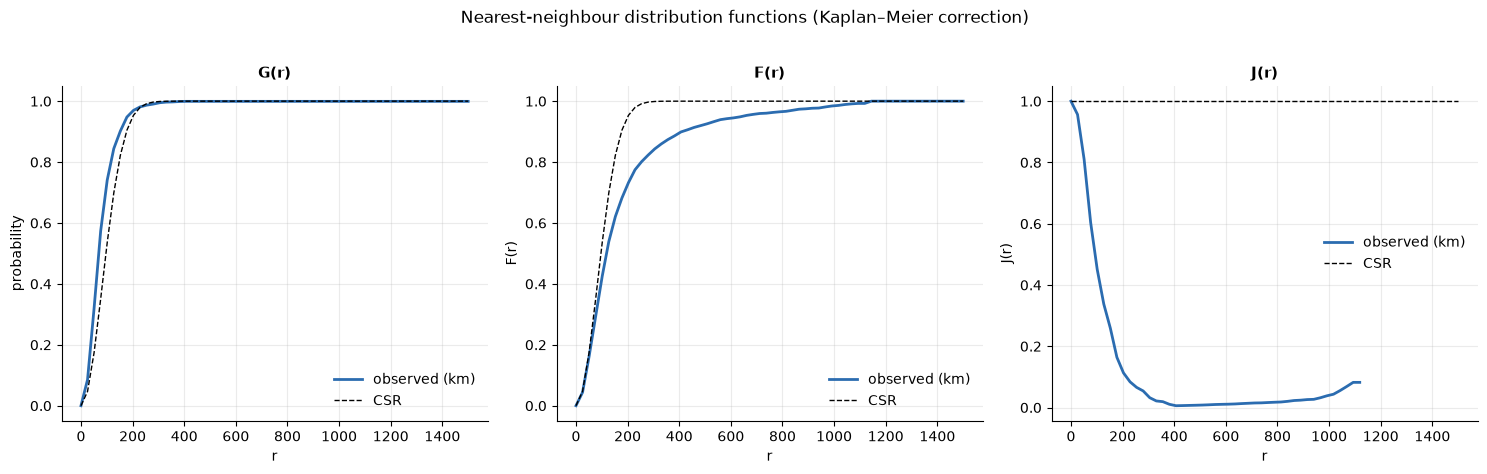

share of 0 < r ≤ 228 m with G(r) above the CSR curve : 1.00  (clustering pushes G up)
share of 0 < r ≤ 228 m with F(r) above the CSR curve : 0.00  (clustering pulls F down, so this should be low)
J(r) stays finite up to r = 1119 m in this sample (40 of 55 points beyond r = 127 m)
share of those finite points with J(r) below 1                : 1.00  (clustering pushes J below 1)


In [4]:
g = g_function(pp_sub, r_range)
f = f_function(pp_sub, r_range)
j = j_function(pp_sub, r_range)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, fn, label in zip(axes, [g, f, j], ["G(r)", "F(r)", "J(r)"]):
    fn.plot(ax=ax, color=C["blue"], lw=2)
    ax.set_title(label)
axes[0].set_ylabel("probability"); axes[2].set_ylabel("J(r)")
plt.suptitle("Nearest-neighbour distribution functions (Kaplan–Meier correction)", y=1.02)
plt.tight_layout(); plt.show()

# Both G(r) and F(r) are bounded above by 1, and the expected CSR nearest-neighbour distance here is only
# about 103 m (lambda = n/area) -- so by r ~= 250 m the *theoretical* CSR curve has already climbed to
# roughly 0.99, leaving almost no room for the comparison to be informative. We therefore look at the
# short-range window where the curves have not yet saturated.
short_range = (r_range > 0) & (r_range <= 228)
above_G = np.mean(g.estimate[short_range] > g.theoretical[short_range])
above_F = np.mean(f.estimate[short_range] > f.theoretical[short_range])   # clustering pulls F BELOW theo, so this should be low

# J(r) becomes undefined once F(r) reaches (numerically) 1: with a finite grid of test locations,
# every grid point eventually lies within r of *some* event, so 1 - F(r) -> 0. Restrict the summary
# to the r where J is still finite, and use np.isfinite explicitly: a NaN < 1 comparison silently
# evaluates to False in NumPy, which would understate "share below 1" if left unmasked.
j_finite = np.isfinite(j.estimate) & (r_range >= r_range[5])
below_J = np.mean(j.estimate[j_finite] < 1)
r_last_finite = r_range[np.isfinite(j.estimate)][-1]

print(f"share of 0 < r ≤ 228 m with G(r) above the CSR curve : {above_G:.2f}  (clustering pushes G up)")
print(f"share of 0 < r ≤ 228 m with F(r) above the CSR curve : {above_F:.2f}  (clustering pulls F down, so this should be low)")
print(f"J(r) stays finite up to r = {r_last_finite:.0f} m in this sample "
      f"({j_finite.sum()} of {(r_range >= r_range[5]).sum()} points beyond r = {r_range[5]:.0f} m)")
print(f"share of those finite points with J(r) below 1                : {below_J:.2f}  (clustering pushes J below 1)")

Over the short-range window, $G$ sits clearly above the CSR curve and $F$ clearly below it — both agree with
clustering, independently, and the gap is substantial: at $r \approx 100$ m (close to the CSR-expected
nearest-neighbour distance of 103 m here) $\hat{G}$ is about 0.74 against a CSR value of 0.54, and $\hat{F}$ is
about 0.43 against a CSR value of 0.54.

Beyond roughly 250 m the comparison stops being informative, for a structural reason worth understanding rather
than a data problem: **both $G(r)$ and $F(r)$ are bounded above by 1**, and with an expected CSR nearest-neighbour
distance of only about 103 m here, the *theoretical* CSR curve itself has already climbed to about 0.99 by
$r = 250$ m. Two curves both pinned near their ceiling leave almost no room for a meaningful comparison, and tiny
sampling fluctuations there can even push the ranking either way — which is exactly the same ceiling effect,
carried one step further, that makes $J(r)$ undefined once $F(r)$ reaches 1 exactly (it stays finite only up to
about 1,140 m here). **Read $G$, $F$ and $J$ at short range, where the theoretical curve has not yet saturated —
this is the region the Clark–Evans index (Section 7) and the pair correlation function (Section 10) target
directly.**

***
## 9. Ripley's K and L Functions

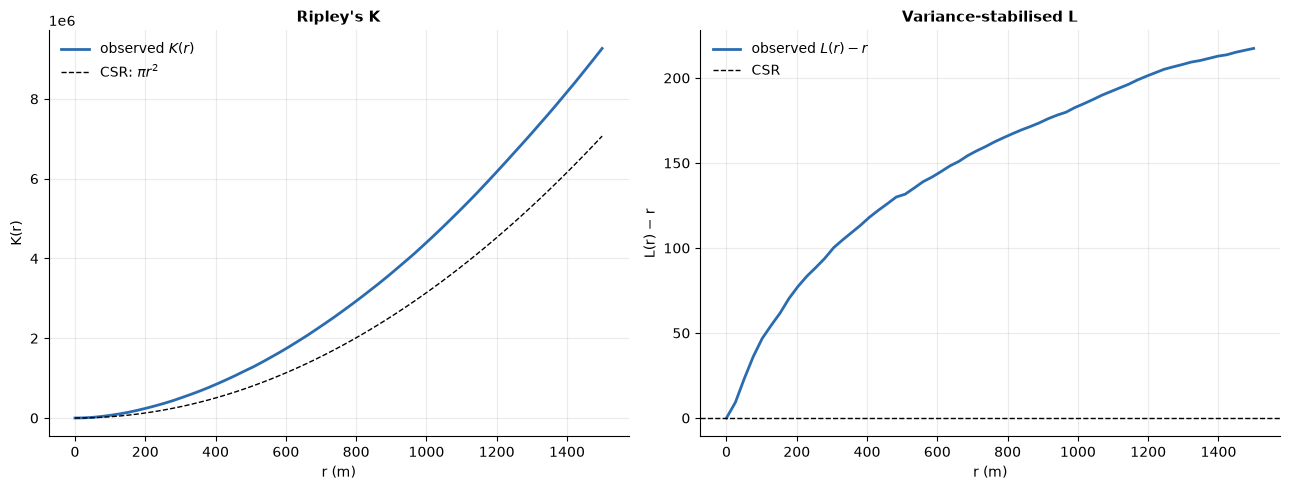

K(r) / (pi r^2) at selected distances:
  r =   150 m : 1.97× CSR
  r =   500 m : 1.58× CSR
  r =  1000 m : 1.40× CSR
  r =  1500 m : 1.31× CSR


In [5]:
k = ripley_k(pp_sub, r_range)
l = ripley_l(pp_sub, r_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(k.r, k.estimate, color=C["blue"], lw=2, label="observed $K(r)$")
axes[0].plot(k.r, k.theoretical, "k--", lw=1, label=r"CSR: $\pi r^2$")
axes[0].set_xlabel("r (m)"); axes[0].set_ylabel("K(r)"); axes[0].legend(); axes[0].set_title("Ripley's K")

axes[1].plot(l.r, l.estimate - l.r, color=C["blue"], lw=2, label="observed $L(r) - r$")
axes[1].axhline(0, color="k", ls="--", lw=1, label="CSR")
axes[1].set_xlabel("r (m)"); axes[1].set_ylabel("L(r) − r"); axes[1].legend()
axes[1].set_title("Variance-stabilised L")
plt.tight_layout(); plt.show()

ratio_at = {int(rv): float(k.estimate[np.searchsorted(r_range, rv)] / k.theoretical[np.searchsorted(r_range, rv)])
           for rv in [150, 500, 1000, 1500]}
print("K(r) / (pi r^2) at selected distances:")
for rv, ratio in ratio_at.items():
    print(f"  r = {rv:5d} m : {ratio:.2f}× CSR")

$K(r)$ is above $\pi r^2$ at every distance examined, and by a **larger factor at short range than at long
range** — clustering is strongest close-up and gradually dilutes as $r$ grows (which is exactly what $K$'s
cumulative nature predicts once the excess pairs from short range keep getting divided by an ever-larger
$\pi r^2$). $L(r) - r$ shows the same story on the easier-to-read variance-stabilised scale: a curve that starts
well above zero and slowly relaxes toward it.

***
## 10. Pair Correlation Function

Because $g(r)$ is not cumulative, it can show something $K$ and $L$ cannot: **whether the interaction is
concentrated at a particular scale**, rather than being a slowly fading tail of the same short-range effect.

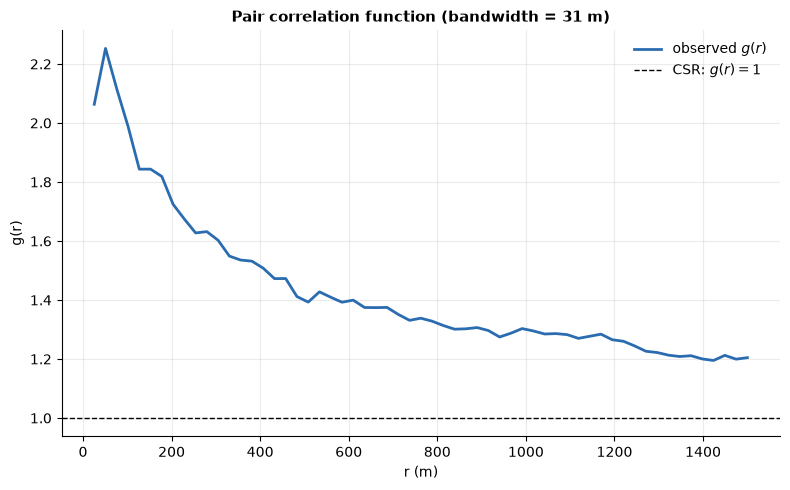

g(r) at r ≈ 50 m  : 2.25
g(r) at r ≈ 300 m : 1.60
g(r) at r ≈ 1000 m: 1.30
g(r) at r ≈ 1500 m: 1.20


In [6]:
g_pc = pair_correlation(pp_sub, r_range[1:])   # g(r) undefined at r = 0

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(g_pc.r, g_pc.estimate, color=C["blue"], lw=2, label="observed $g(r)$")
ax.axhline(1.0, color="k", ls="--", lw=1, label="CSR: $g(r) = 1$")
ax.set_xlabel("r (m)"); ax.set_ylabel("g(r)")
ax.set_title(f"Pair correlation function (bandwidth = {g_pc['bandwidth']:.0f} m)")
ax.legend()
plt.tight_layout(); plt.show()

print(f"g(r) at r ≈ 50 m  : {g_pc.estimate[np.searchsorted(g_pc.r, 50)]:.2f}")
print(f"g(r) at r ≈ 300 m : {g_pc.estimate[np.searchsorted(g_pc.r, 300)]:.2f}")
print(f"g(r) at r ≈ 1000 m: {g_pc.estimate[np.searchsorted(g_pc.r, 1000)]:.2f}")
print(f"g(r) at r ≈ 1500 m: {g_pc.estimate[np.searchsorted(g_pc.r, 1500)]:.2f}")

$g(r)$ is highest at the shortest distances and **decays toward 1** as $r$ grows — clear evidence that the
clustering signal is genuinely concentrated at short range (a few hundred metres: the scale of a city block or
two), not a diffuse effect smeared across the whole city. This is the piece of information that $K(r) - \pi r^2$
and $L(r) - r$, by construction, cannot show directly: they stay elevated at large $r$ even after the local
clustering effect has essentially vanished, simply because they accumulate everything from zero up to $r$.

***
## 11. Comparing Edge Corrections

We now hold the statistic fixed (Ripley's $K$) and vary only the edge correction, to see the bias that Section
4.4 described rather than take it on faith.

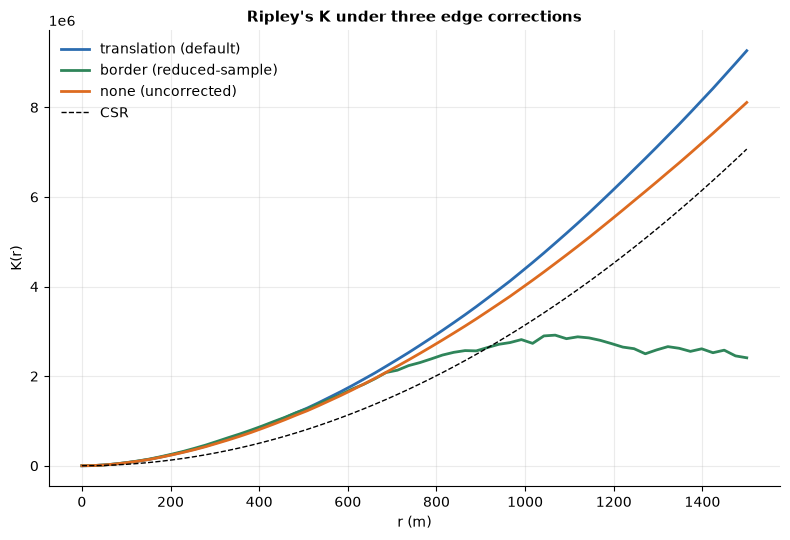

uncorrected K as a fraction of the translation-corrected K, at increasing r:
  r =   254 m : none = 0.975×   border = 1.056×
  r =   763 m : none = 0.933×   border = 0.857×
  r =  1500 m : none = 0.875×   border = 0.260×

at r = 1500 m: only 48 of 2,500 events (1.9%) are far enough from the boundary to serve as a border-correction anchor, and the window eroded by r has shrunk to 3.8 km² (from 105.8 km² originally).


In [7]:
k_trans = ripley_k(pp_sub, r_range, correction="translation")
k_border = ripley_k(pp_sub, r_range, correction="border")
k_none = ripley_k(pp_sub, r_range, correction="none")

fig, ax = plt.subplots(figsize=(8, 5.5))
for res, label, color in [(k_trans, "translation (default)", C["blue"]),
                          (k_border, "border (reduced-sample)", C["green"]),
                          (k_none, "none (uncorrected)", C["orange"])]:
    ax.plot(res.r, res.estimate, color=color, lw=2, label=label)
ax.plot(r_range, np.pi * r_range ** 2, "k--", lw=1, label="CSR")
ax.set_xlabel("r (m)"); ax.set_ylabel("K(r)")
ax.set_title("Ripley's K under three edge corrections")
ax.legend()
plt.tight_layout(); plt.show()

with np.errstate(invalid="ignore"):
    rel_none = k_none.estimate / k_trans.estimate
    rel_border = np.where(np.isfinite(k_border.estimate), k_border.estimate / k_trans.estimate, np.nan)
print("uncorrected K as a fraction of the translation-corrected K, at increasing r:")
for i in [10, 30, 59]:
    print(f"  r = {r_range[i]:5.0f} m : none = {rel_none[i]:.3f}×   border = {rel_border[i]:.3f}×"
          + ("  (border undefined here)" if np.isnan(rel_border[i]) else ""))

# why border degrades at large r: how many anchors remain, and how much of the window is left after erosion?
b_dist = pp_sub.window.distance_to_boundary(pp_sub.coords)
r_big = r_range[59]
n_anchors = int((b_dist >= r_big).sum())
eroded_km2 = pp_sub.window.polygon.buffer(-r_big).area / 1e6
print(f"\nat r = {r_big:.0f} m: only {n_anchors} of {pp_sub.n:,} events "
      f"({100 * n_anchors / pp_sub.n:.1f}%) are far enough from the boundary to serve as a border-correction "
      f"anchor, and the window eroded by r has shrunk to {eroded_km2:.1f} km² "
      f"(from {pp_sub.window.area / 1e6:.1f} km² originally).")

The uncorrected ("none") estimate falls further below the translation-corrected curve as $r$ grows — exactly
the low bias Section 4.4 predicted, since a larger radius means a larger share of events have part of their
neighbourhood cut off by the boundary with no correction applied.

The border correction tracks the translation correction reasonably at moderate $r$, but **breaks down sharply**
by $r = 1{,}500$ m: only a couple of percent of events are far enough from Buffalo's boundary to qualify as an
"anchor" at that radius, and the window eroded by 1,500 m has shrunk to a few percent of its original area — a
small, geometrically peculiar leftover fragment of the city, not a representative interior. Border estimates
built from so little data are necessarily unstable, and should not be trusted as $r$ approaches a sizeable
fraction of the window's own extent. **The default, `'translation'`, is the sensible general-purpose choice**
used throughout this chapter and the rest of Part 1: it uses every event at every $r$, at the cost of a raster
approximation on non-rectangular windows (Section 4.4).

***
## 12. Summary and Conclusions

### What we did

1. Distinguished first-order (intensity, Chapter 1.2) from second-order (interaction) structure, and
   introduced the four families of summary function that quantify the latter.
2. Prepared a deduplicated, fixed-size working subsample, and explained why deduplication (not jittering)
   is the right choice for distance-based statistics.
3. Computed the Clark–Evans index ($R \approx 0.5$, strongly significant clustering).
4. Computed $G$, $F$ and $J$, all three agreeing on short-range clustering.
5. Computed Ripley's $K$ and its variance-stabilised form $L(r) - r$, both elevated above the CSR line at every
   distance examined, most strongly at short range.
6. Computed the pair correlation function $g(r)$, which **localised** the clustering to roughly a few hundred
   metres — information the cumulative K/L functions could not show directly.
7. Compared three edge corrections on the same data and observed the uncorrected estimator's bias grow with $r$,
   exactly as the theory predicted.

### Practical takeaways

- **Deduplicate before computing distances.** Repeated geocoded coordinates are a data artefact that second-
  order statistics will happily (and wrongly) read as extreme clustering.
- **No single function tells the whole story.** Clark–Evans gives one number; $G$/$F$/$J$ and $K$/$L$ give
  curves; only $g(r)$ localises *where* on the distance axis the interaction lives. Use $g(r)$ whenever the
  scale of clustering, not just its presence, is the question.
- **Always state the edge correction.** `'translation'` is the safe default; `'none'` should not be used for
  anything beyond a quick sanity check, because its bias grows with $r$.
- Every method here found clustering. Chapter 1.4 asks the next, harder question: is that clustering still
  present once the known, strongly non-constant *intensity* from Chapter 1.2 is accounted for — or could an
  inhomogeneous but otherwise independent process explain it just as well?

### Next steps

**Chapter 1.4 (Hypothesis Testing and Model Extensions)** turns today's descriptive curves into formal Monte
Carlo tests with simulation envelopes, calibrates them against known clustered and regular processes, and
introduces the inhomogeneous K function — which asks about interaction *after* removing a known intensity
trend, rather than assuming a constant background rate.

***
## 13. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Ripley, B. D. (1981). *Spatial Statistics*. Wiley. | The original systematic treatment of K, L and edge correction |
| Baddeley, A., Rubak, E. & Turner, R. (2015). *Spatial Point Patterns: Methodology and Applications with R*. CRC Press. | Chapters 7–8: nearest-neighbour and second-order functions in depth, with the `spatstat` implementation this package's API is modelled on |
| Diggle, P. J. (2013). *Statistical Analysis of Spatial and Spatio-Temporal Point Patterns* (3rd ed.). CRC Press. | Concise treatment of G, F, J and K |
| Stoyan, D. & Stoyan, H. (1994). *Fractals, Random Shapes and Point Fields*. Wiley. | The pair correlation function in a broader stochastic-geometry context |

### Key papers

| Paper | Contribution |
|---|---|
| Clark, P. J. & Evans, F. C. (1954). Distance to nearest neighbor as a measure of spatial relationships. *Ecology*, 35, 445–453. | The Clark–Evans index |
| Donnelly, K. (1978). Simulations to determine the variance and edge effect of total nearest neighbour distance. In *Simulation Methods in Archaeology*. | The finite-window correction used by `clark_evans` |
| Ripley, B. D. (1976). The second-order analysis of stationary point processes. *Journal of Applied Probability*, 13, 255–266. | The K function |
| Van Lieshout, M. N. M. & Baddeley, A. J. (1996). A nonparametric measure of spatial interaction in point patterns. *Statistica Neerlandica*, 50, 344–361. | The J function |

### In this library

| Object | Role |
|---|---|
| `spatialstats.pointpattern.clark_evans` | Nearest-neighbour index with Donnelly's finite-window correction |
| `spatialstats.pointpattern.g_function`, `f_function`, `j_function` | Nearest-event, empty-space and combined distribution functions |
| `spatialstats.pointpattern.ripley_k`, `ripley_l` | Cumulative second-order functions with `'translation'`, `'border'`, `'none'` corrections |
| `spatialstats.pointpattern.pair_correlation` | The non-cumulative pair correlation function $g(r)$ |
| Chapter 1.1 | `Window`, `PointPattern`, `deduplicate()`, the CRS correction reused here |
| Chapter 1.4 | Formal Monte Carlo tests (`envelope`), calibration against known processes, `k_inhom` |